# Plots

Below we plot many of the Softjax functions for different modes and softnesses to give an idea of how they look like.
All functions are designed to be soft when used on inputs in an interval [0,1] when setting default softness of 1.0. 
When inputs in other ranges are used, softness can be scaled accrdingly, e.g. on inputs distributed in the inteval [0, 100] a softness of 100.0 should result in a soft behavior.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "high")
# jax.config.update("jax_platforms", "cpu")
import jax.numpy as jnp
import softjax as sj
from plot_utils import configure_plots, plot, plot_softness_sweep


configure_plots()


## Sigmoid-based

In [2]:
modes = ["smooth", "c0", "c1", "c2"]

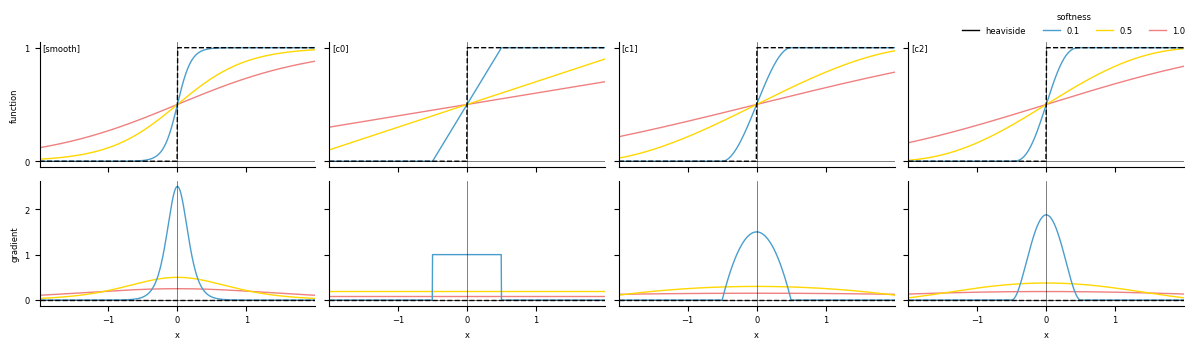

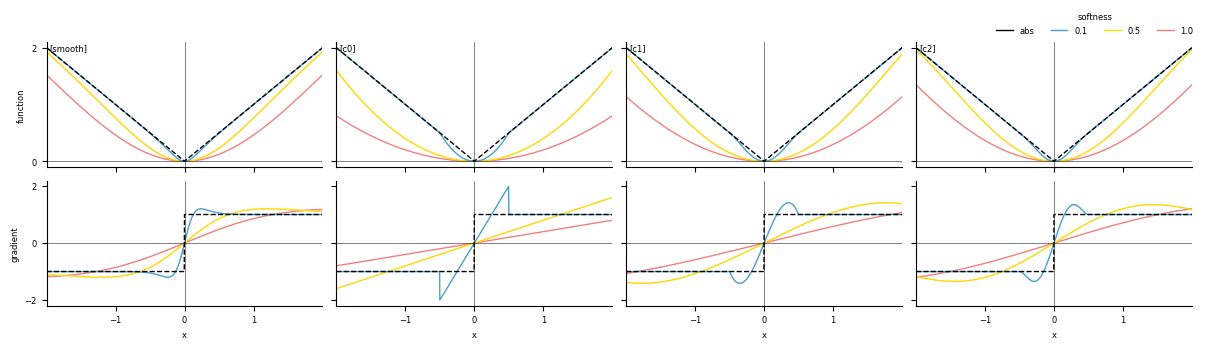

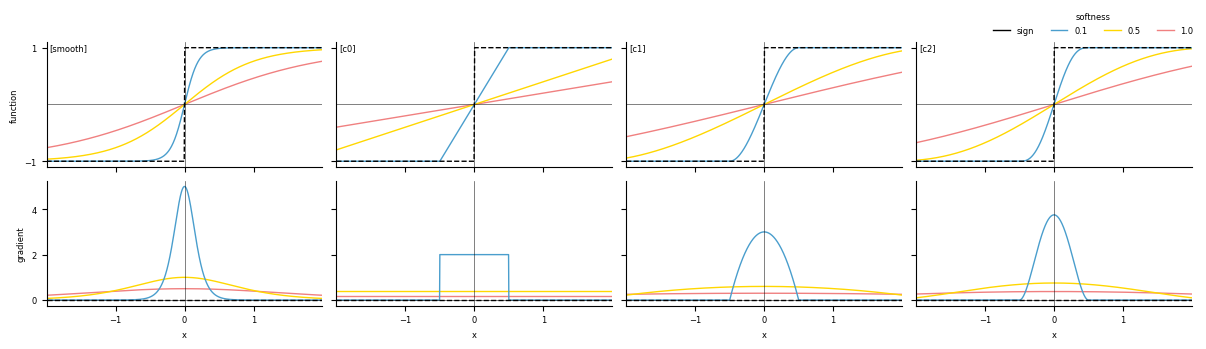

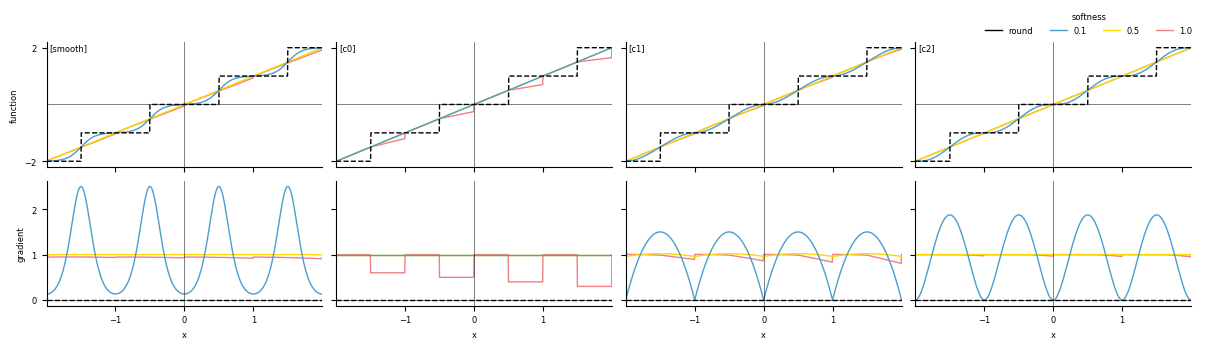

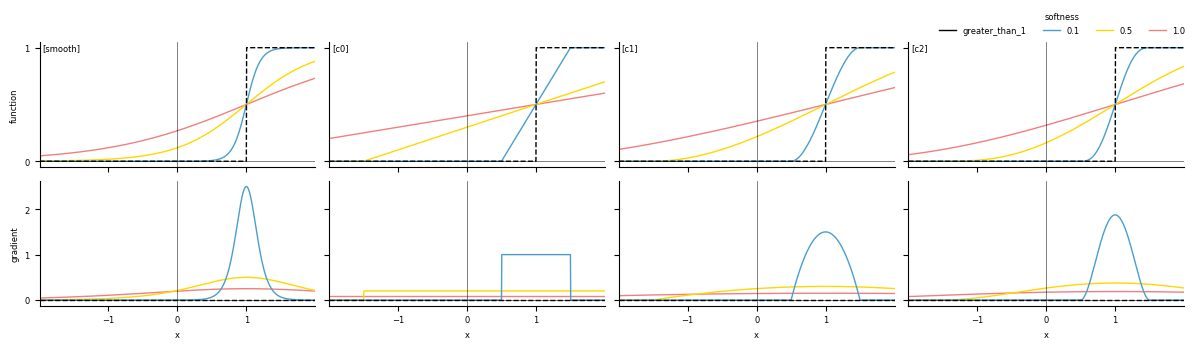

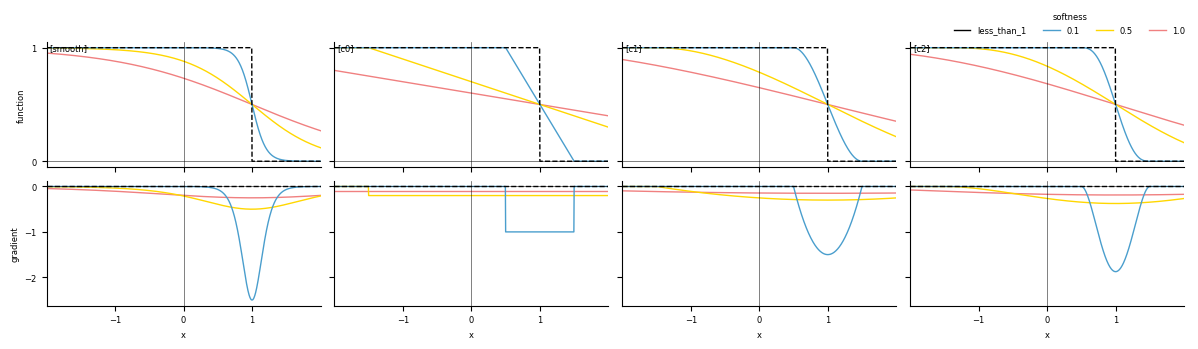

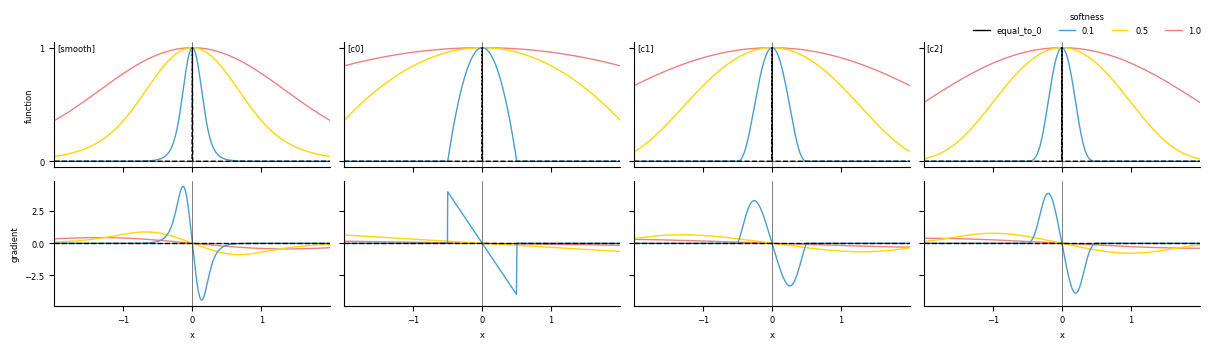

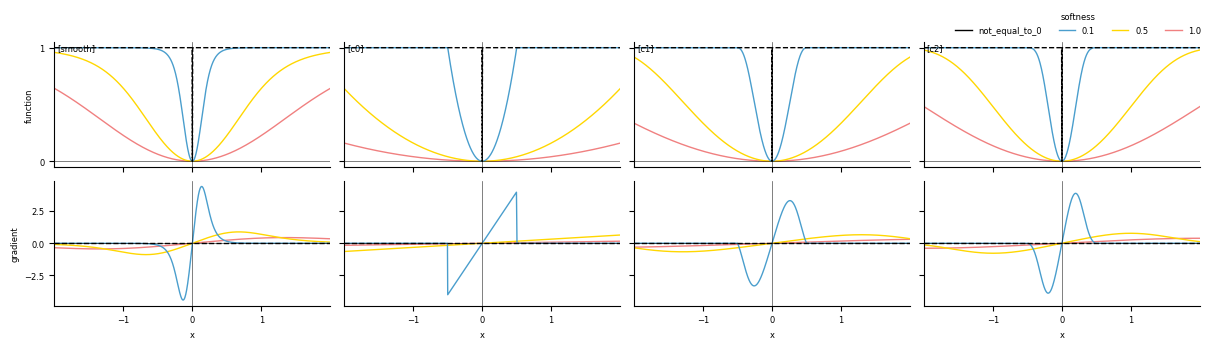

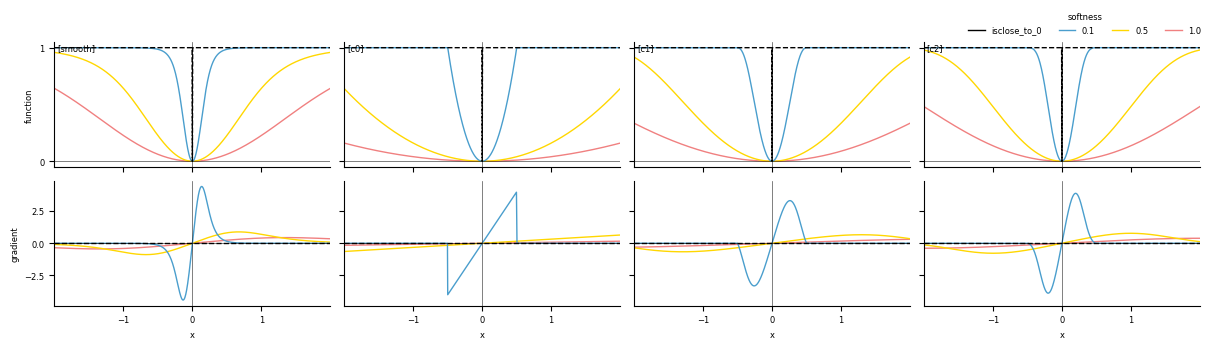

In [3]:
def greater_than_1(x, **kwargs):
    return sj.greater(x, jnp.array(1.0), **kwargs)


def less_than_1(x, **kwargs):
    return sj.less(x, jnp.array(1.0), **kwargs)


def equal_to_0(x, **kwargs):
    return sj.equal(x, jnp.array(0.0), **kwargs)


def not_equal_to_0(x, **kwargs):
    return sj.not_equal(x, jnp.array(0.0), **kwargs)


def isclose_to_0(x, **kwargs):
    return sj.not_equal(x, jnp.array(0.0), **kwargs)


plot(sj.heaviside, modes=modes)
plot(sj.abs, modes=modes)
plot(sj.sign, modes=modes)
plot(sj.round, modes=modes)
plot(greater_than_1, modes=modes)
plot(less_than_1, modes=modes)
plot(equal_to_0, modes=modes)
plot(not_equal_to_0, modes=modes)
plot(isclose_to_0, modes=modes)

## Softplus-based

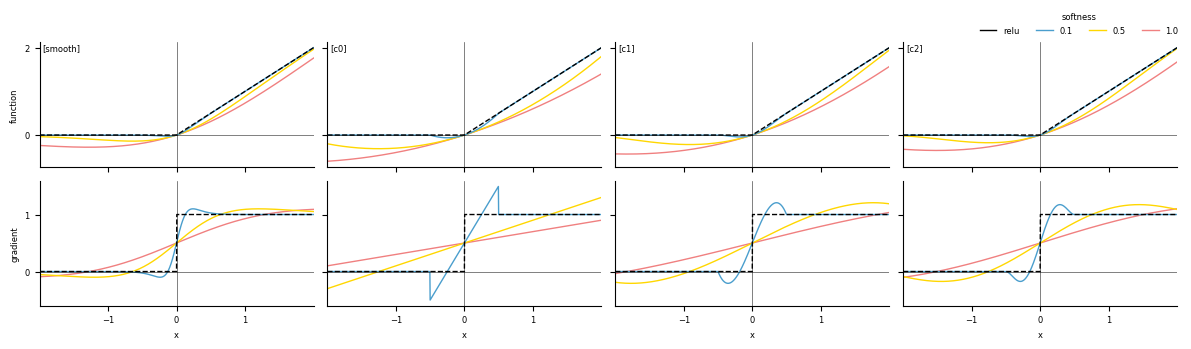

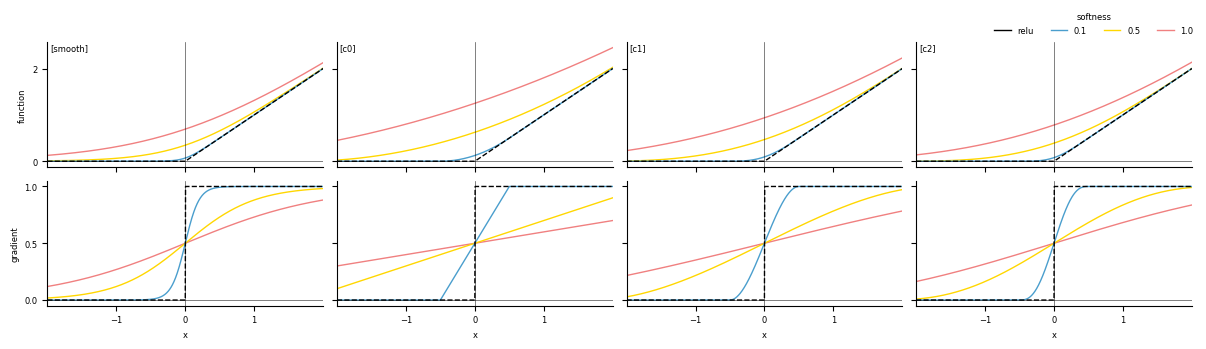

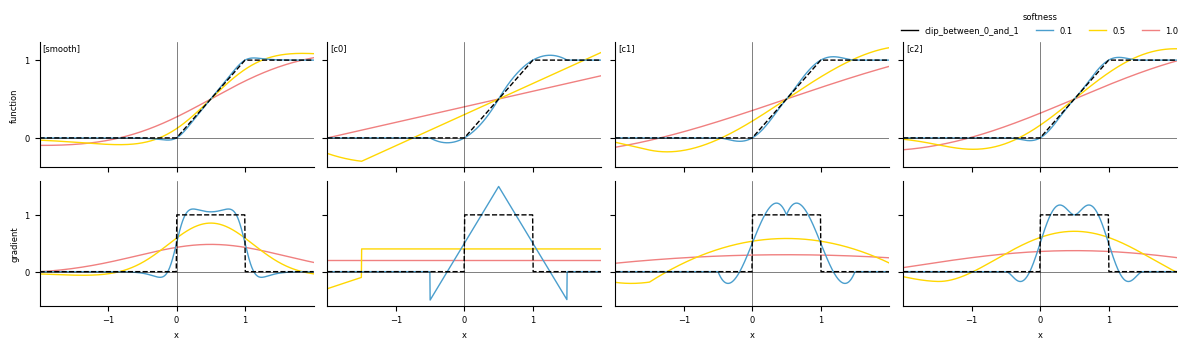

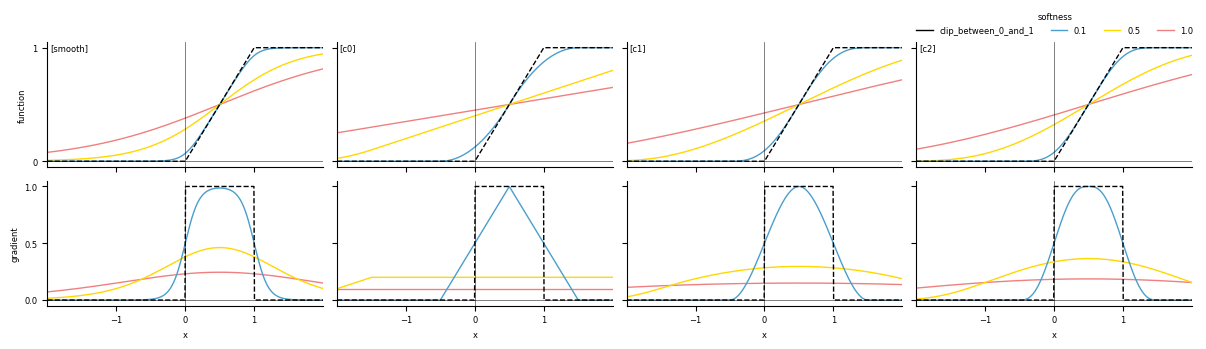

In [4]:
def clip_between_0_and_1(x, **kwargs):
    return sj.clip(x, jnp.array(0.0), jnp.array(1.0), **kwargs)


plot(sj.relu, modes=modes, gated=True)
plot(sj.relu, modes=modes, gated=False)
plot(clip_between_0_and_1, modes=modes, gated=True)
plot(clip_between_0_and_1, modes=modes, gated=False)

## Simplex-projection / optimal transport based

Sort (ot):


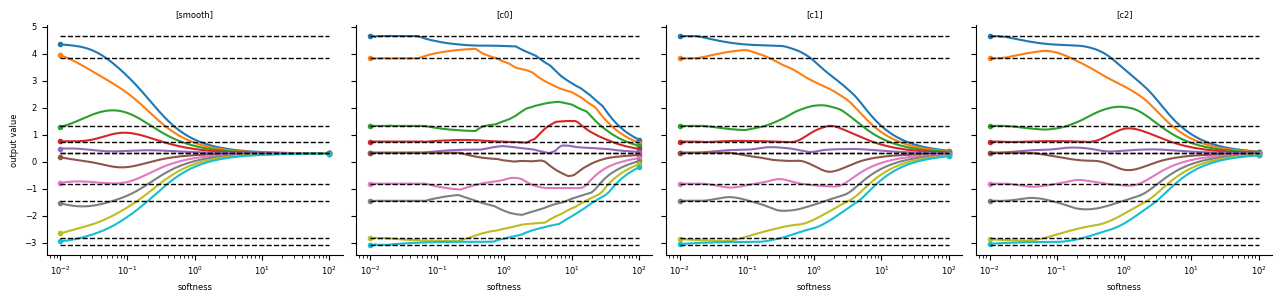

Sort (softsort):


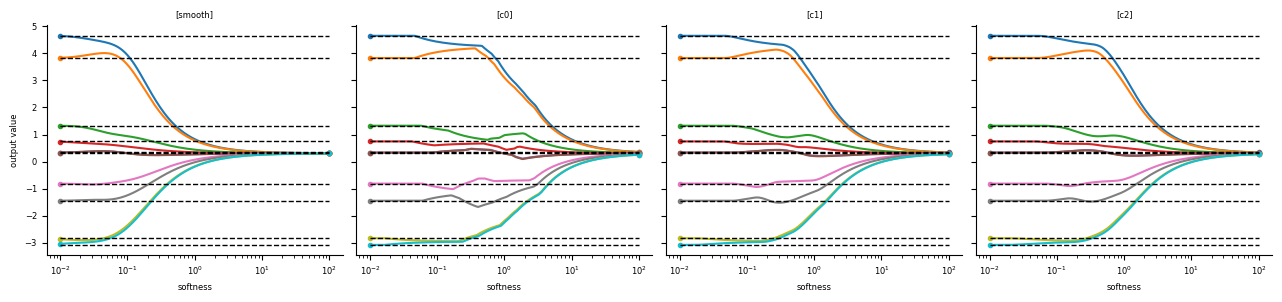

Sort (neuralsort):


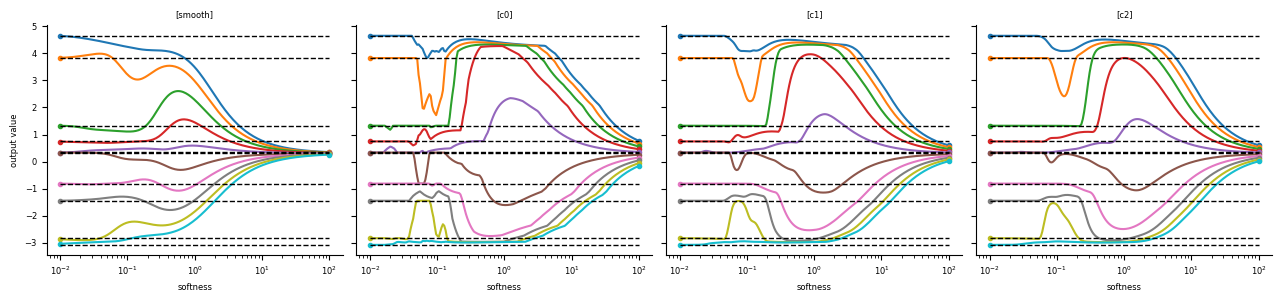

Sort (fast_soft_sort):


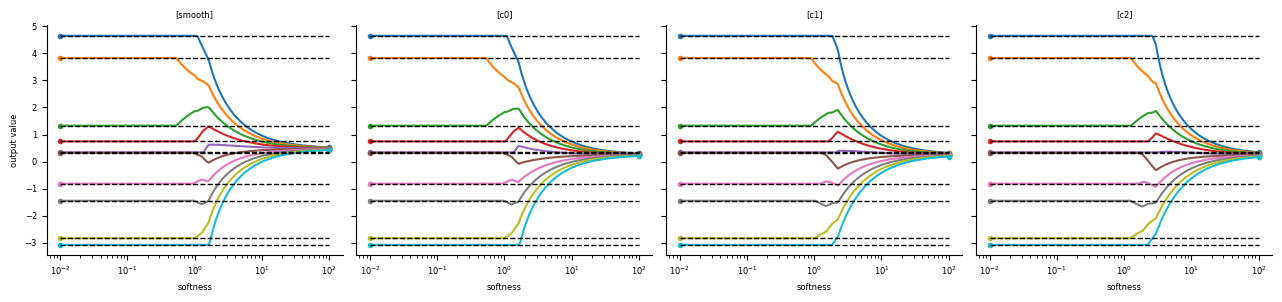

Sort (sorting_network):


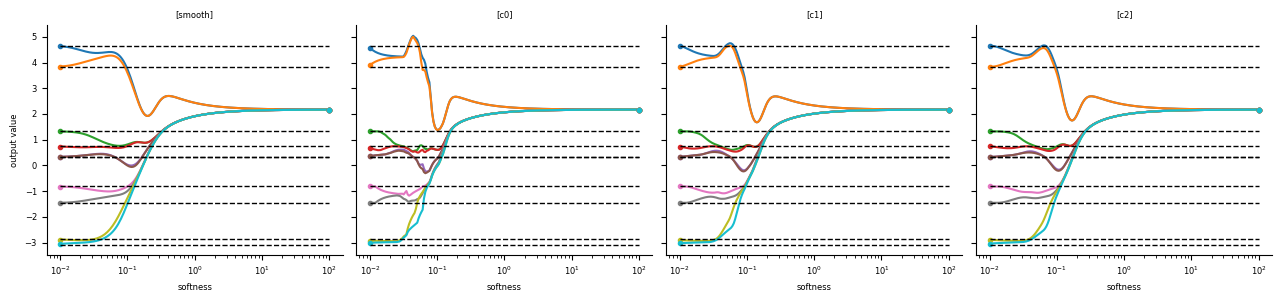

Rank (ot):


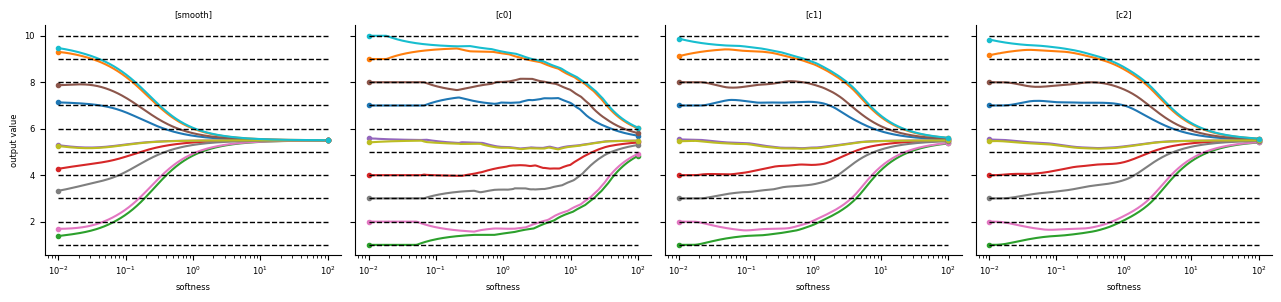

Rank (softsort):


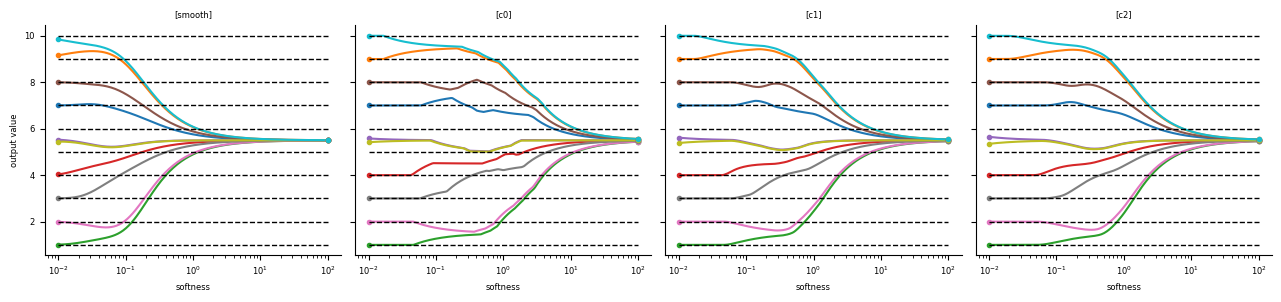

Rank (neuralsort):


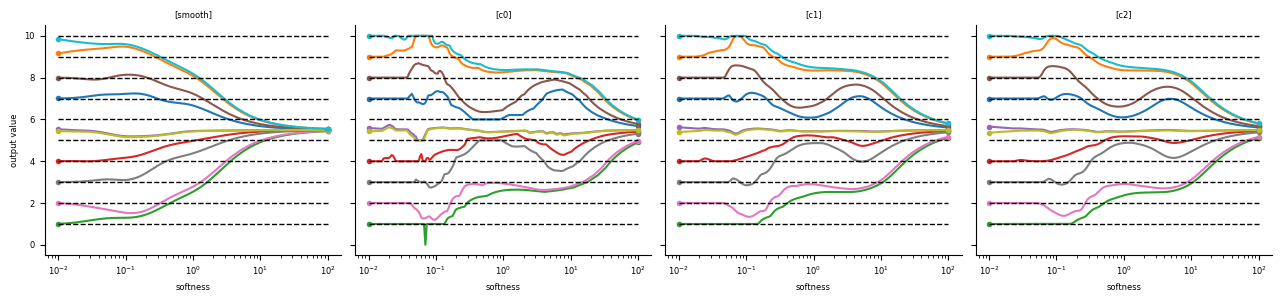

Rank (fast_soft_sort):


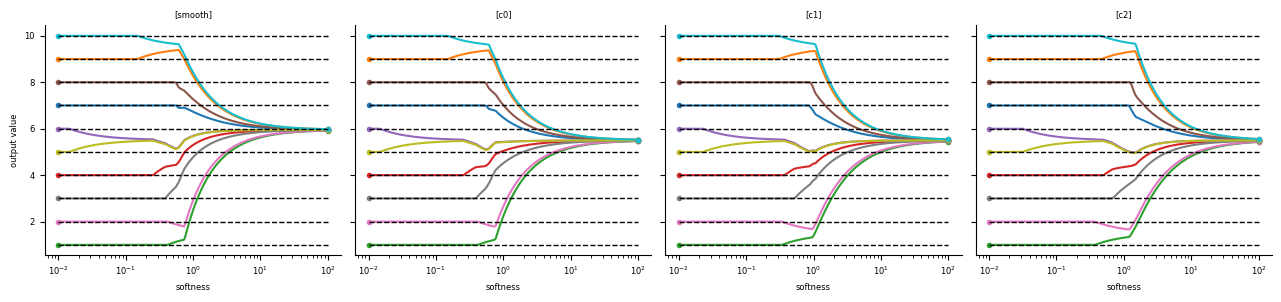

Rank (sorting_network):


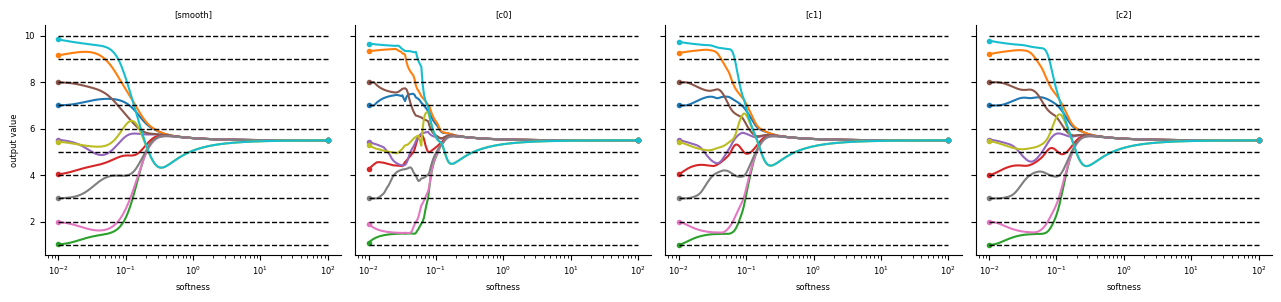

(<Figure size 1280x300 with 4 Axes>,
 array([<Axes: title={'center': '[smooth]'}, xlabel='softness', ylabel='output value'>,
        <Axes: title={'center': '[c0]'}, xlabel='softness'>,
        <Axes: title={'center': '[c1]'}, xlabel='softness'>,
        <Axes: title={'center': '[c2]'}, xlabel='softness'>], dtype=object))

In [5]:
x = jax.random.uniform(jax.random.PRNGKey(0), (10,), minval=-5, maxval=5)
# x = None

print("Sort (ot):")
plot_softness_sweep(sj.sort, modes=modes, method="ot", descending=True, x=x)
print("Sort (softsort):")
plot_softness_sweep(sj.sort, modes=modes, method="softsort", descending=True, x=x)
print("Sort (neuralsort):")
plot_softness_sweep(sj.sort, modes=modes, method="neuralsort", descending=True, x=x)
print("Sort (fast_soft_sort):")
plot_softness_sweep(sj.sort, modes=modes, method="fast_soft_sort", descending=True, x=x)
print("Sort (sorting_network):")
plot_softness_sweep(
    sj.sort, modes=modes, method="sorting_network", descending=True, x=x
)

print("Rank (ot):")
plot_softness_sweep(sj.rank, modes=modes, method="ot", descending=True, x=x)
print("Rank (softsort):")
plot_softness_sweep(sj.rank, modes=modes, method="softsort", descending=True, x=x)
print("Rank (neuralsort):")
plot_softness_sweep(sj.rank, modes=modes, method="neuralsort", descending=True, x=x)
print("Rank (fast_soft_sort):")
plot_softness_sweep(sj.rank, modes=modes, method="fast_soft_sort", descending=True, x=x)
print("Rank (sorting_network):")
plot_softness_sweep(
    sj.rank, modes=modes, method="sorting_network", descending=True, x=x
)


Max


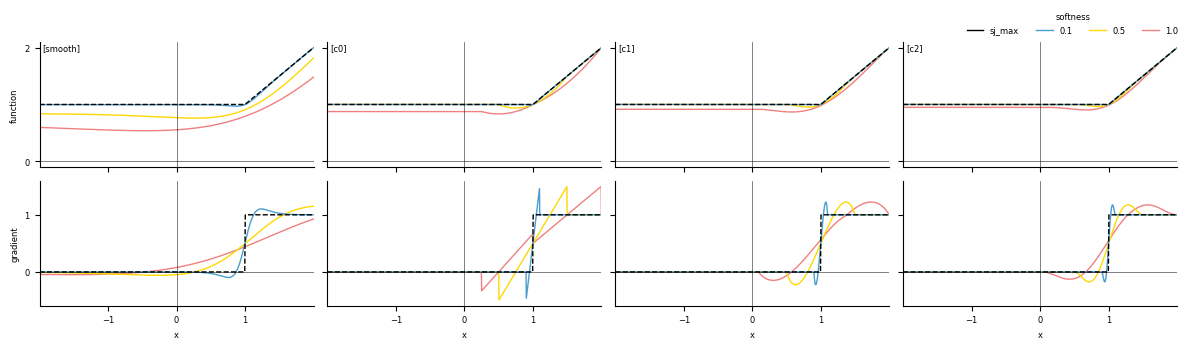

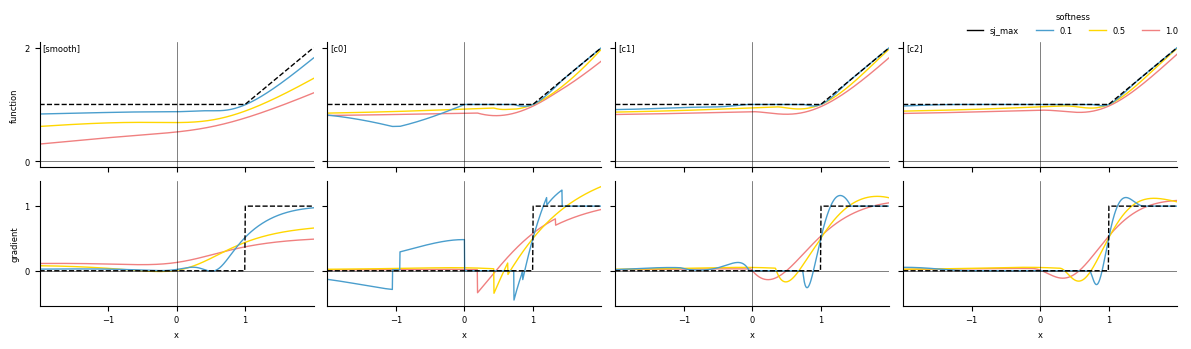

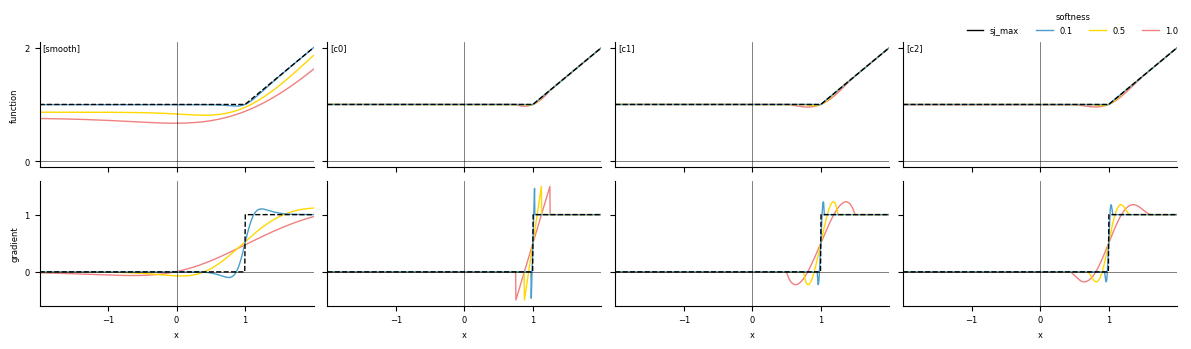

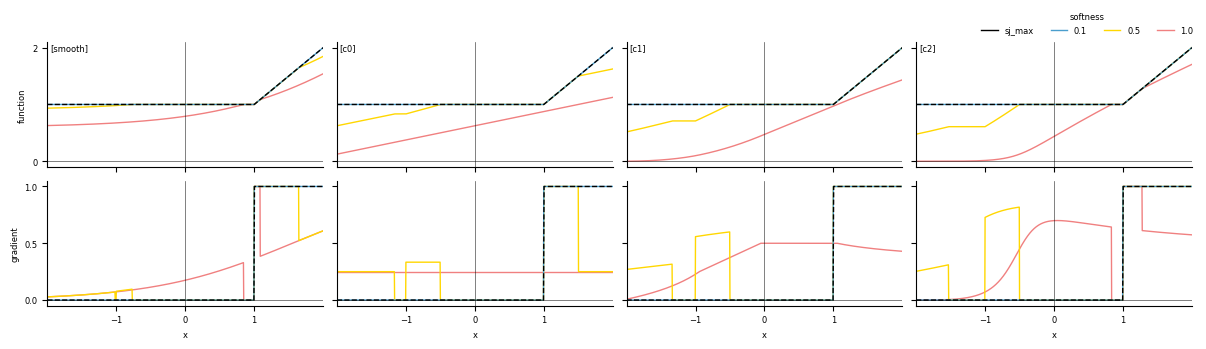

Max_st


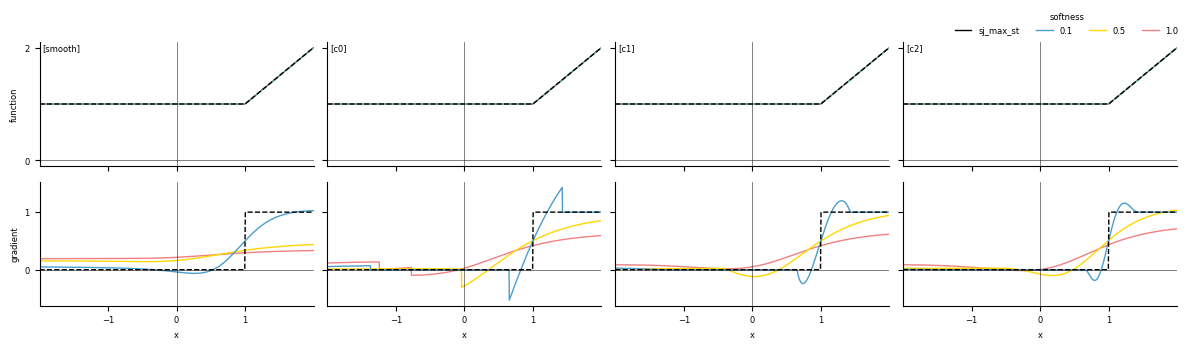

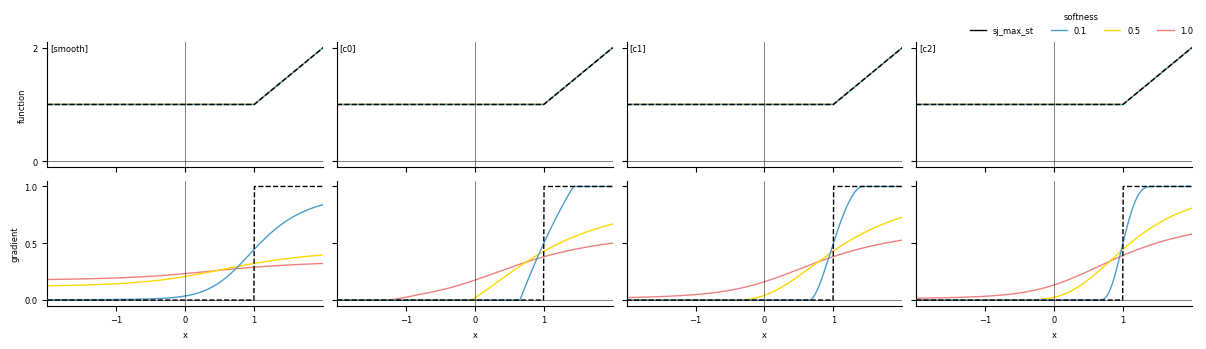

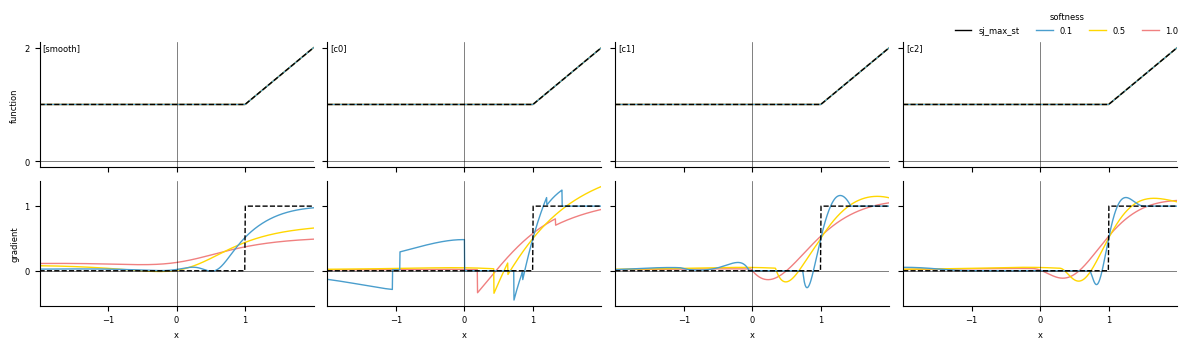

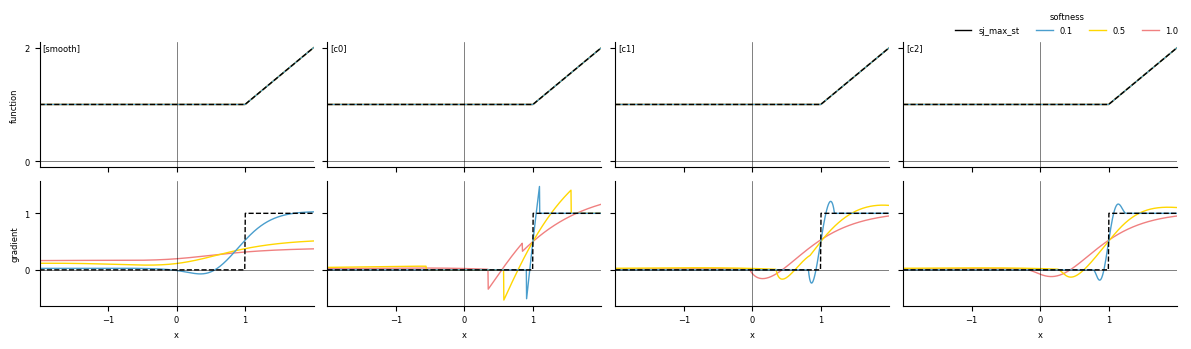

Min


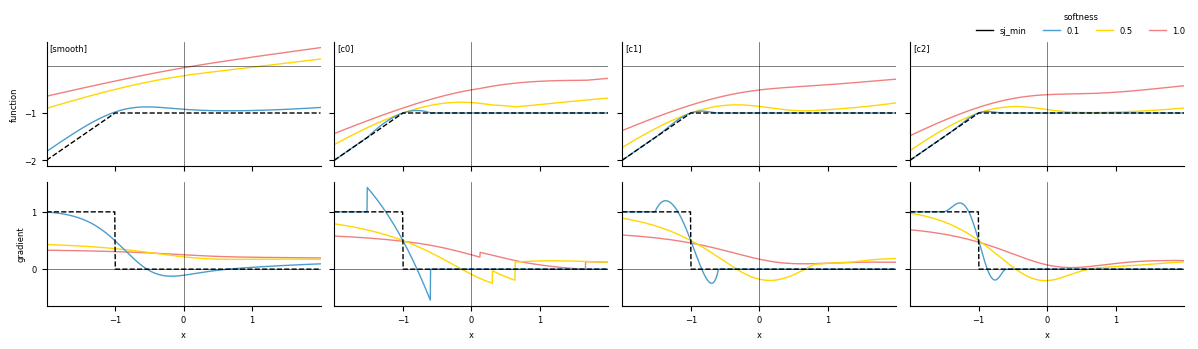

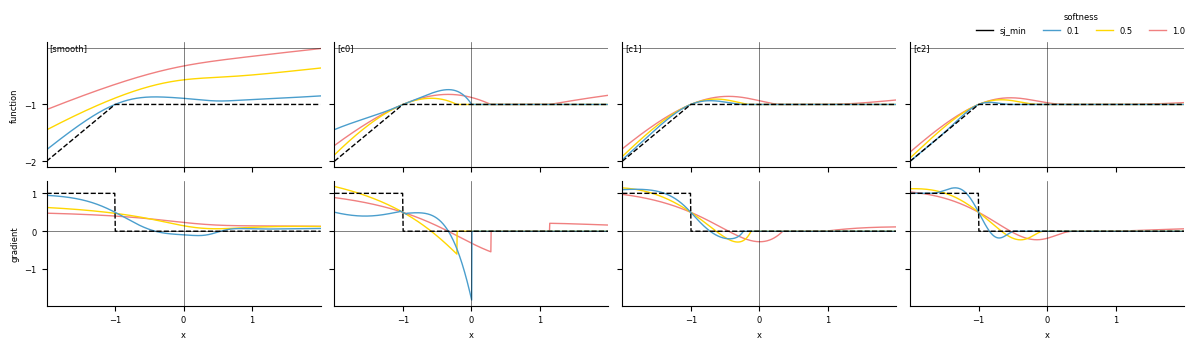

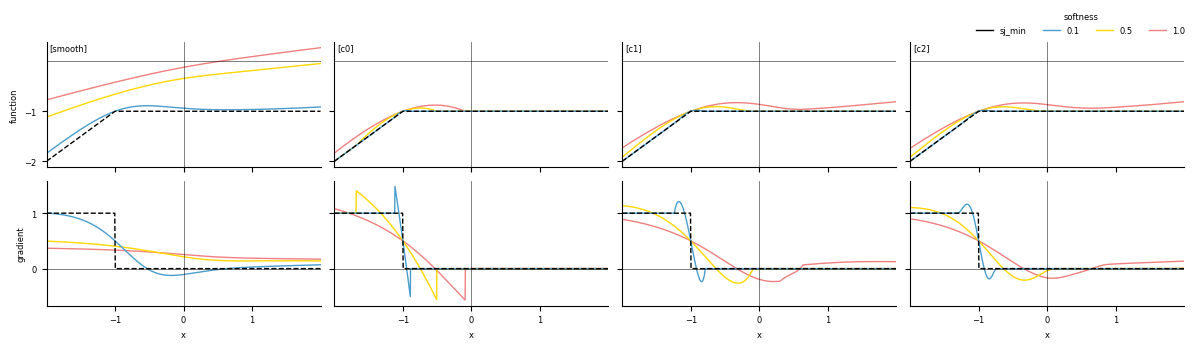

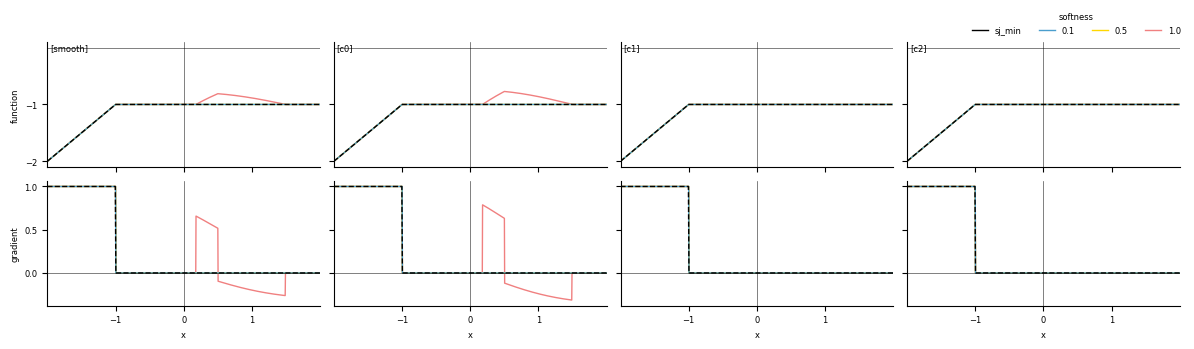

Top K


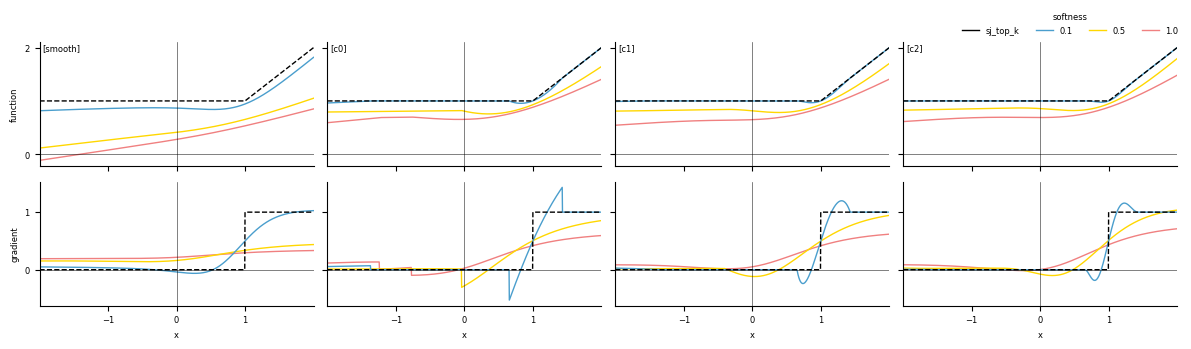

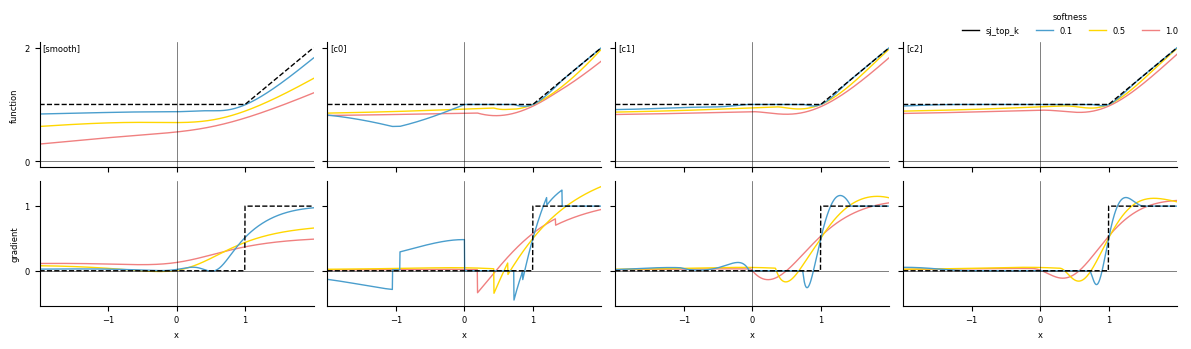

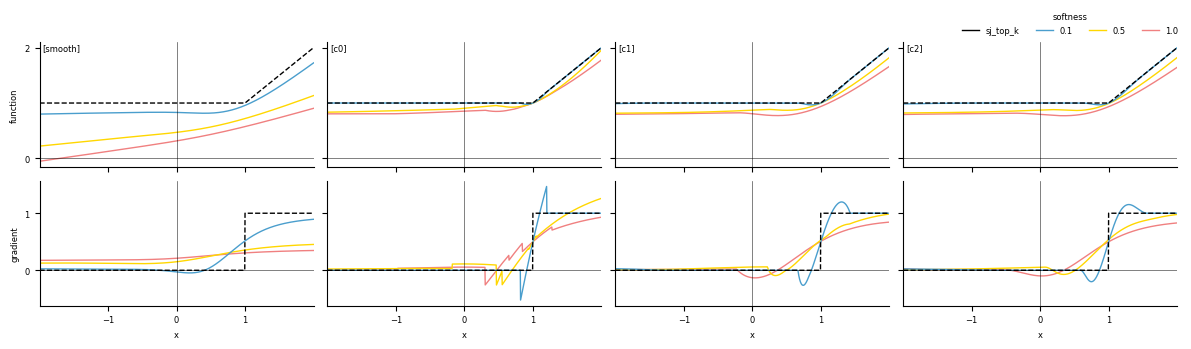

Sort


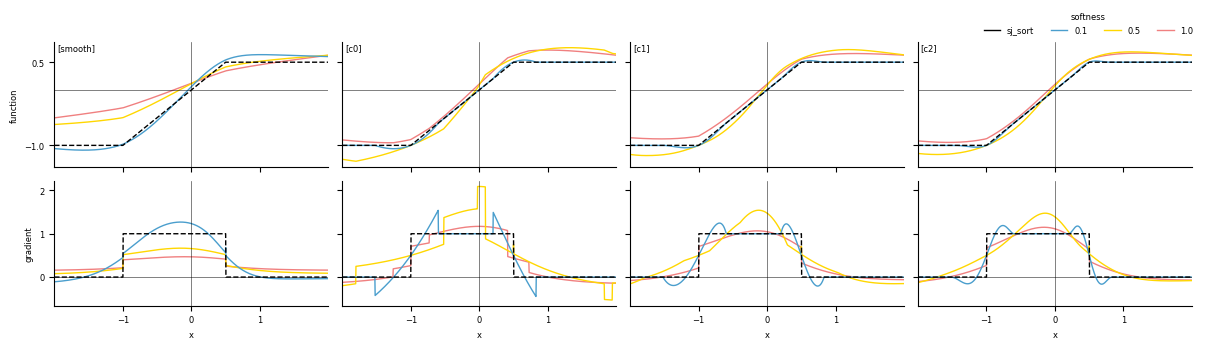

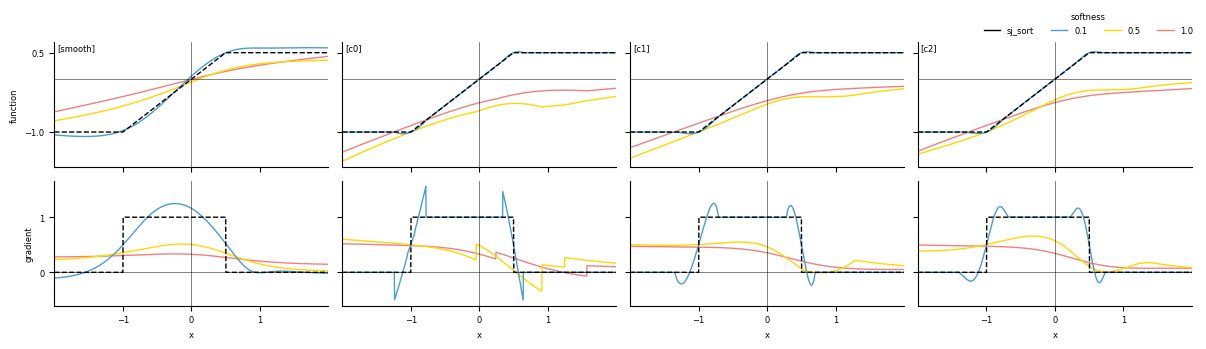

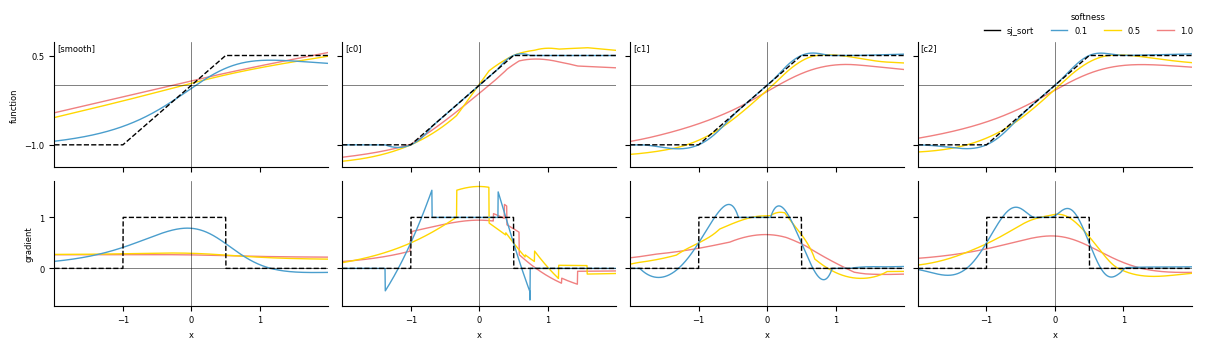

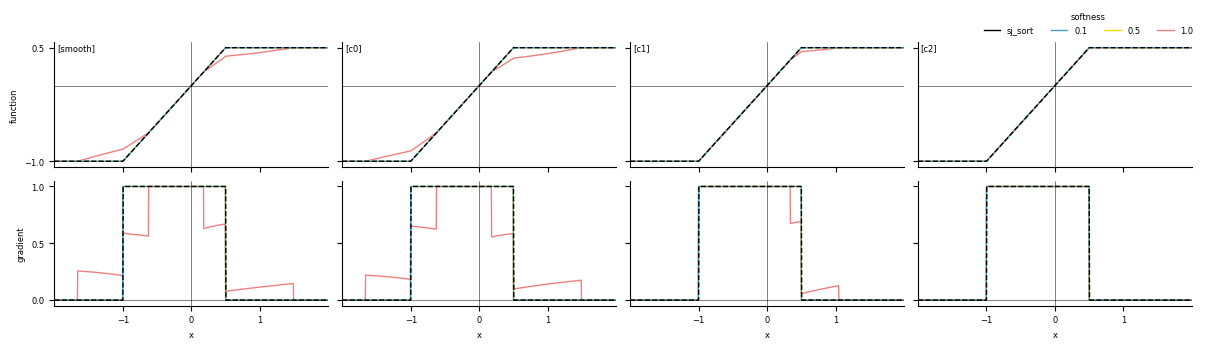

Argort


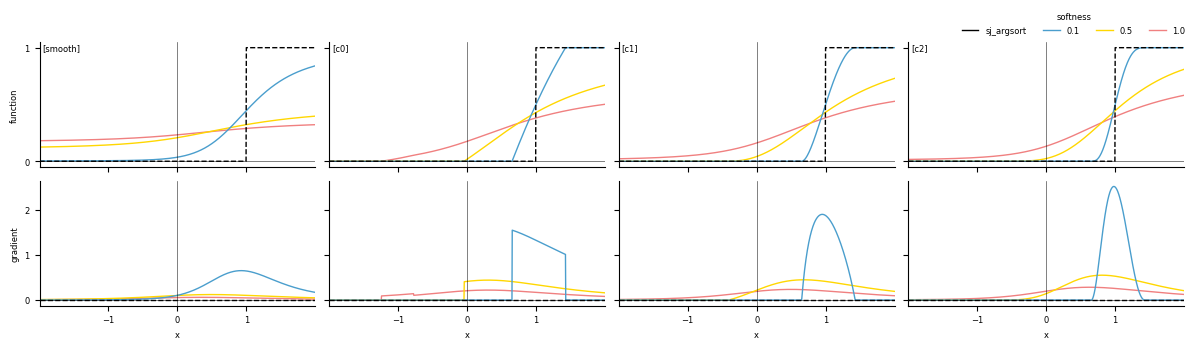

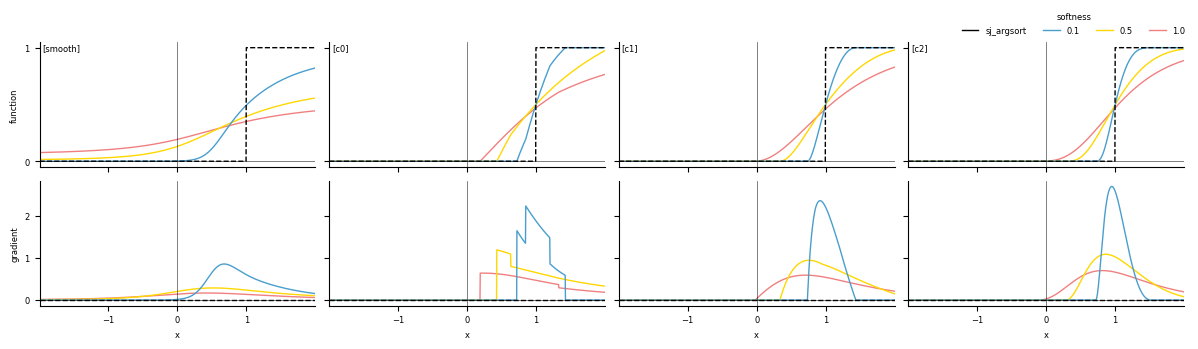

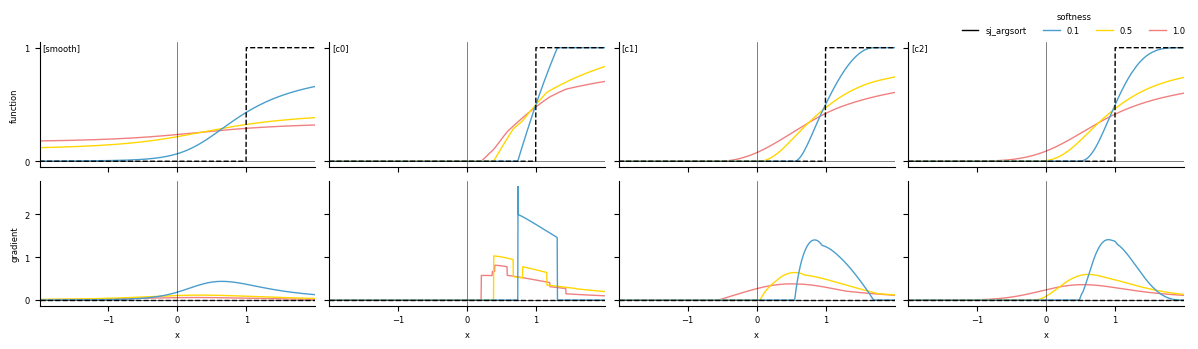

Sort_st


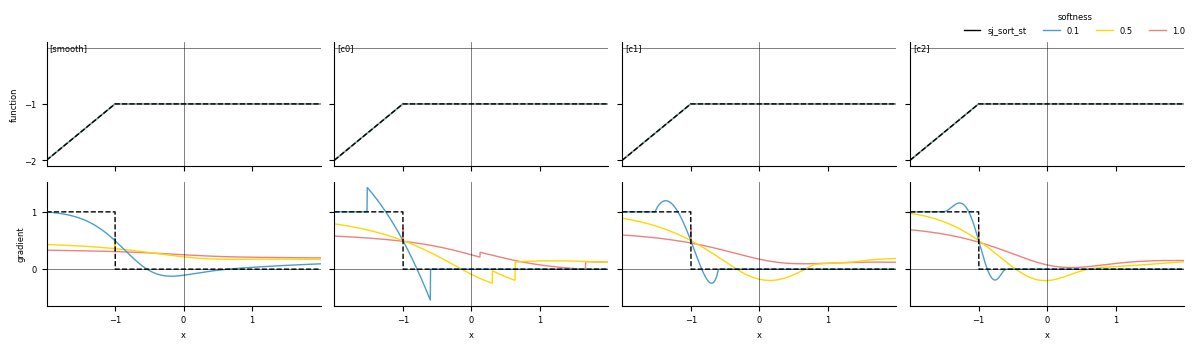

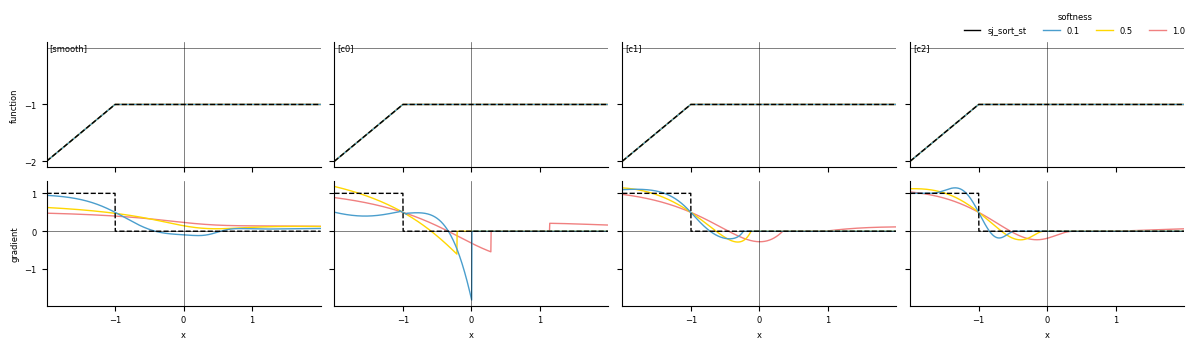

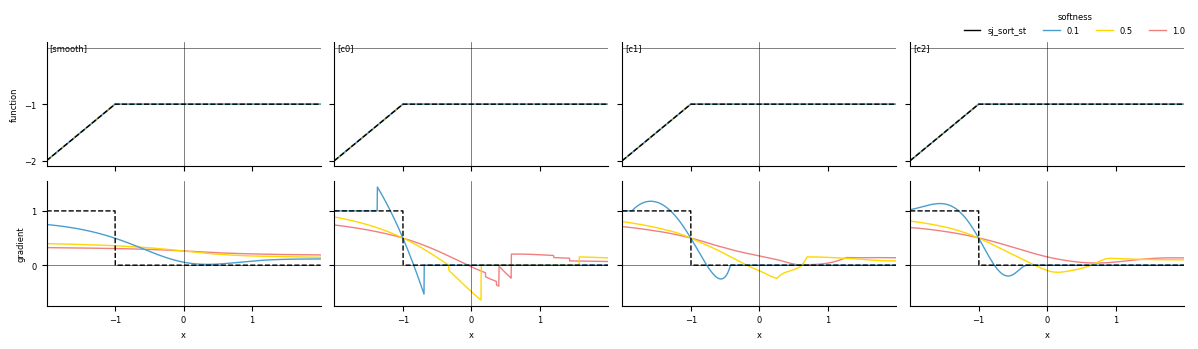

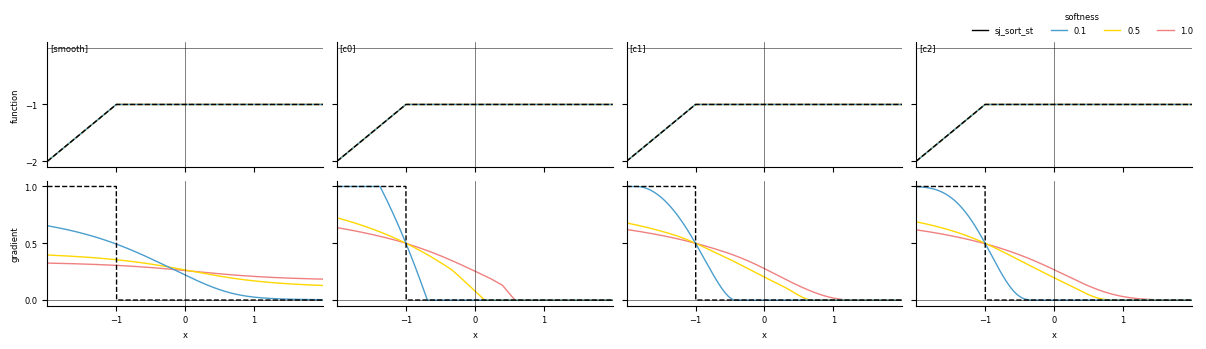

Quantile


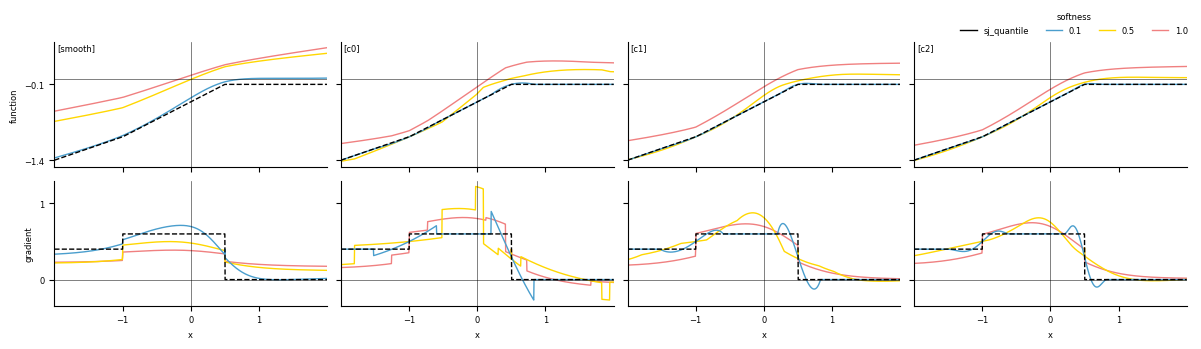

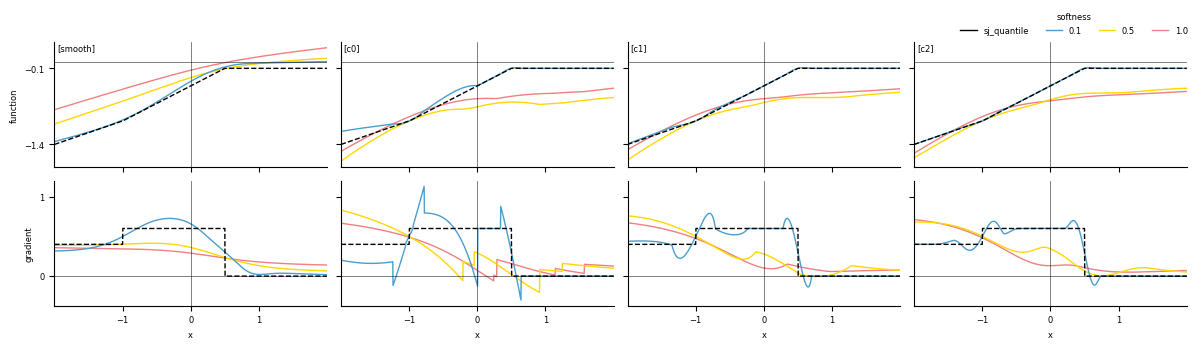

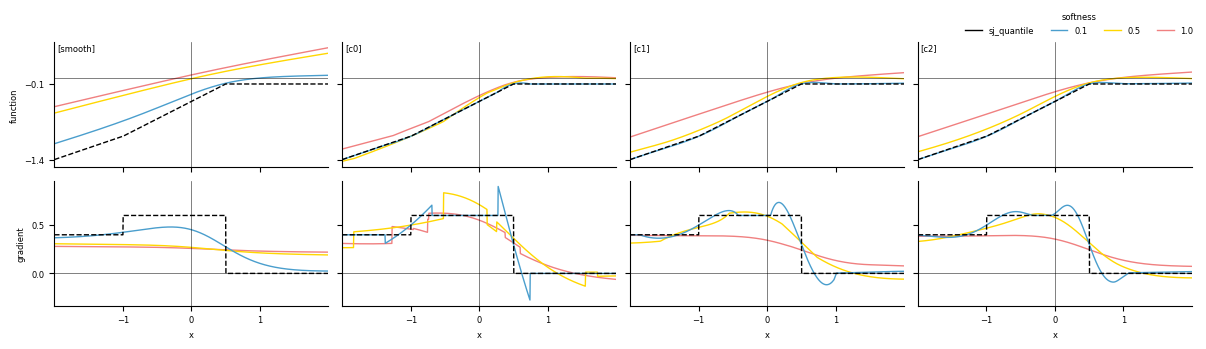

Argquantile


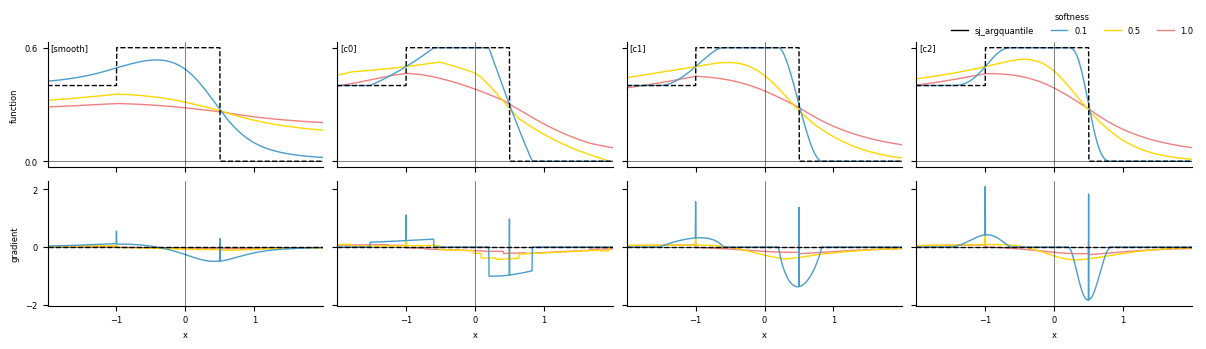

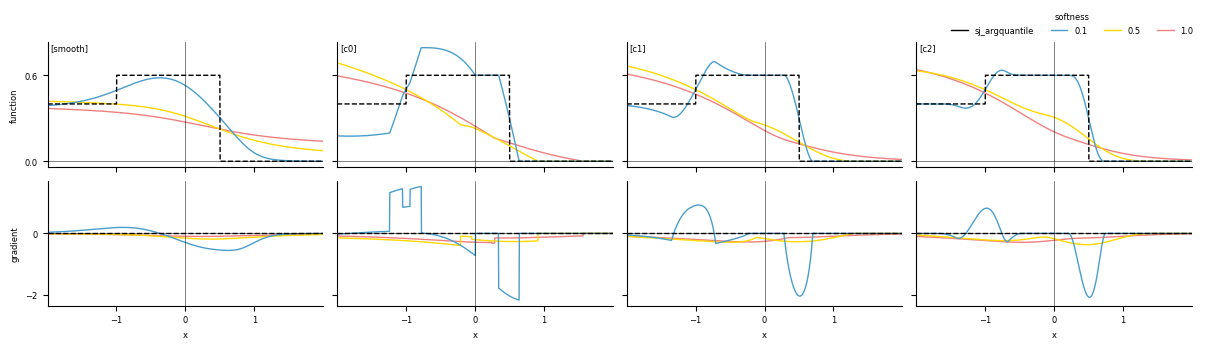

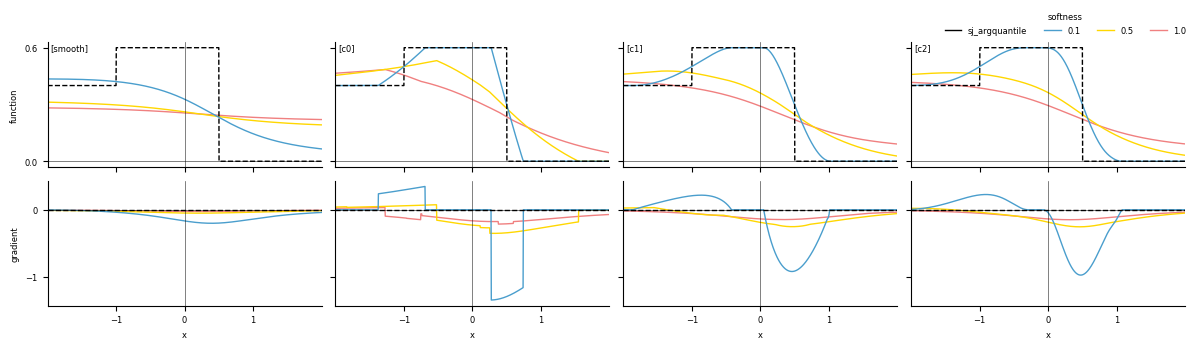

Median


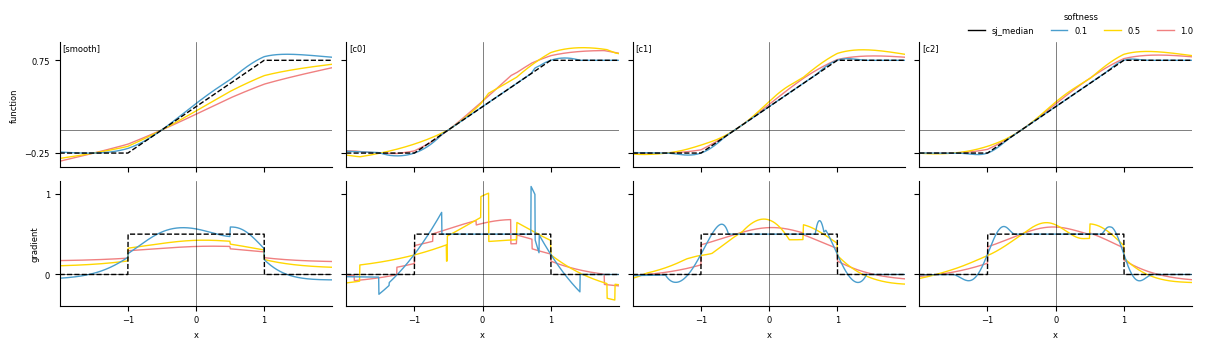

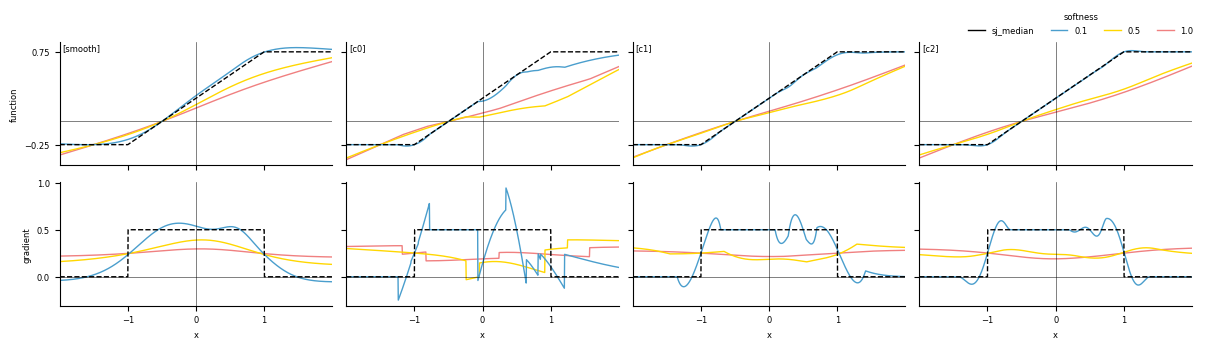

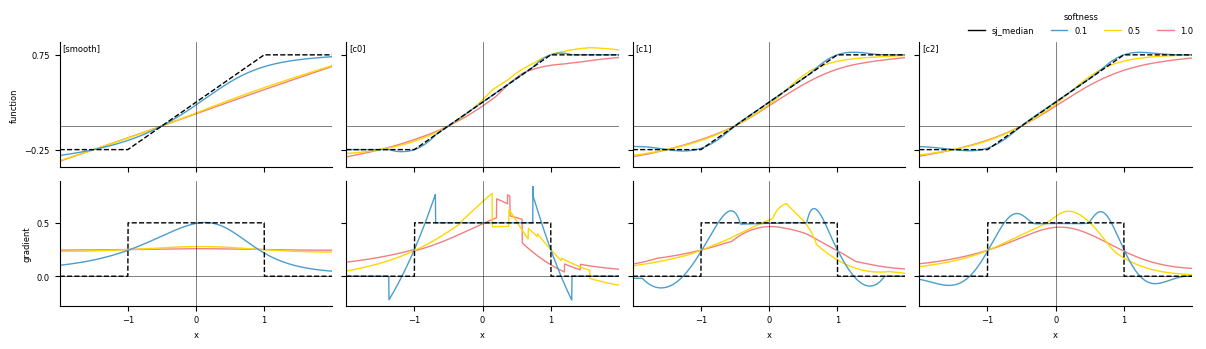

Argmedian


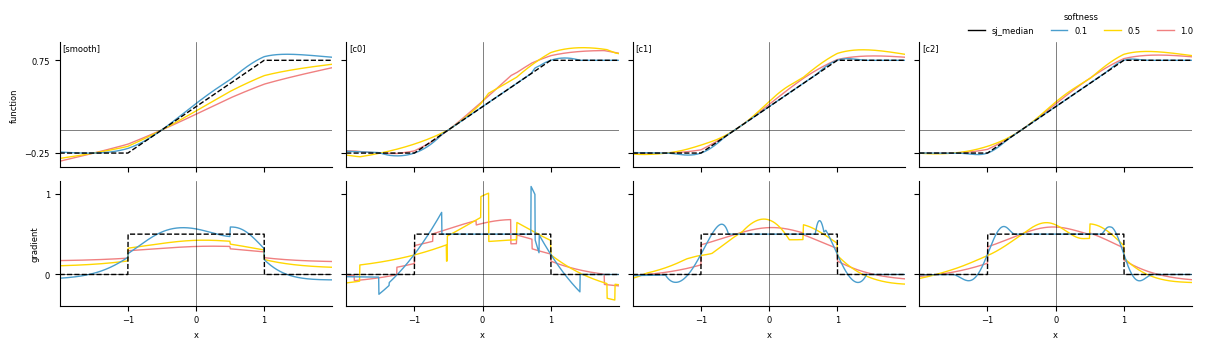

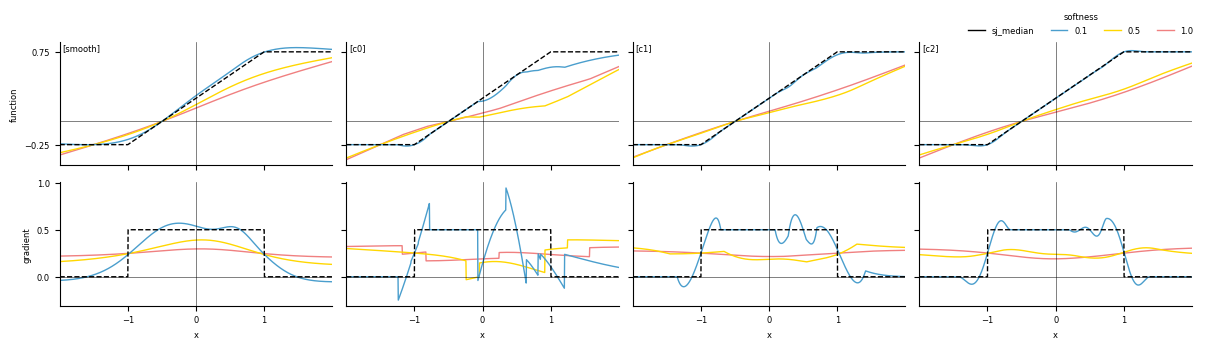

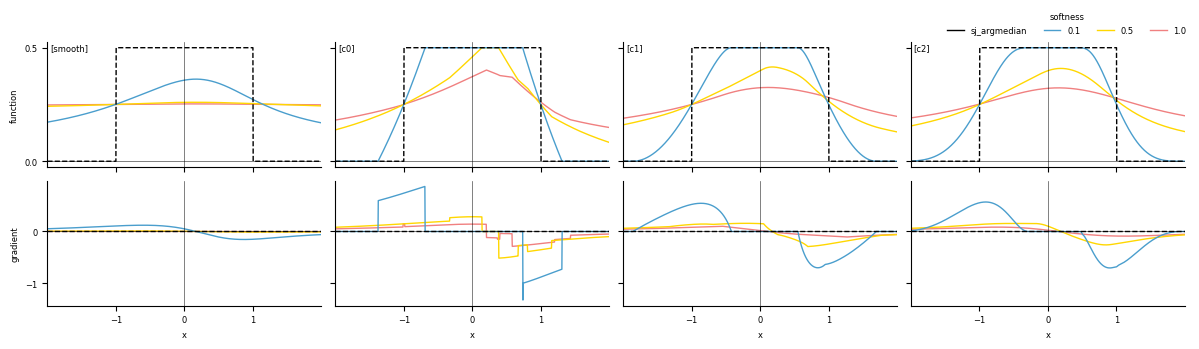

rank


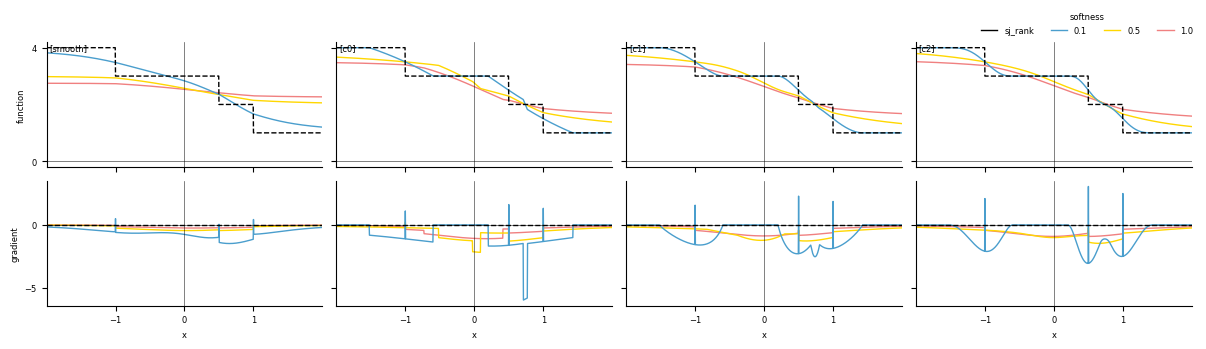

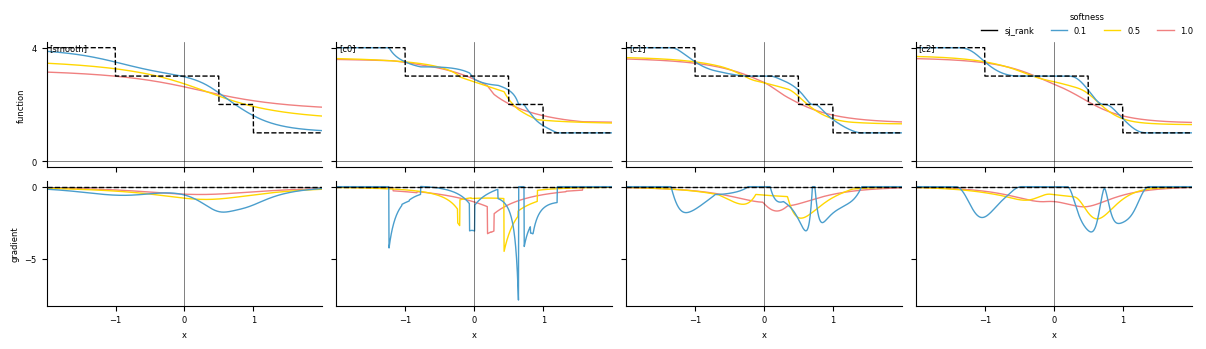

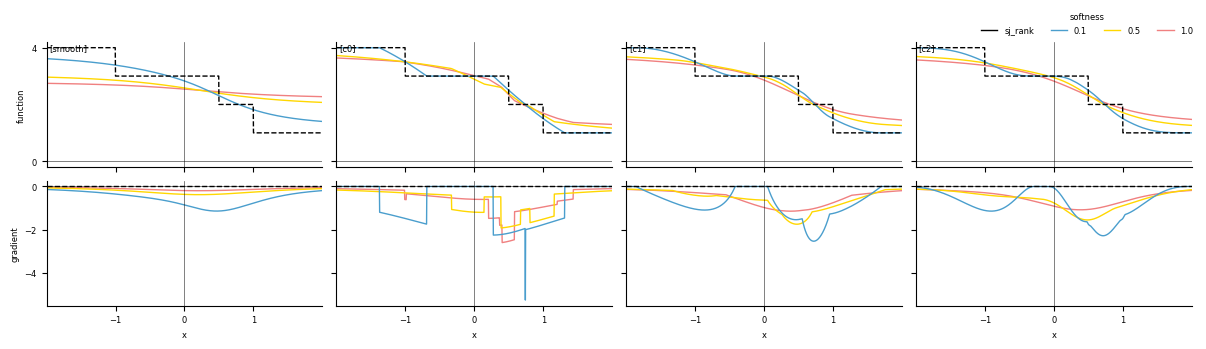

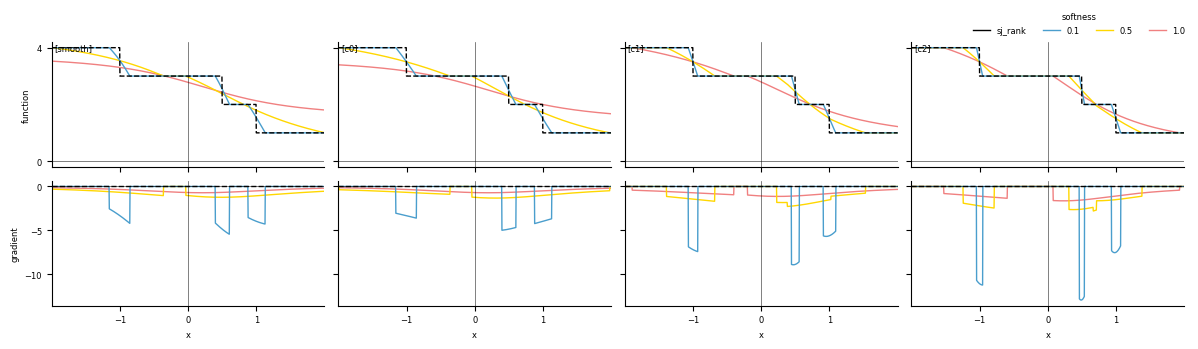

In [6]:
values = [-1.0, 0.5, 1.0]
# values = [0.0]
# values = [0, 3, 2]


def sj_max(x, **kwargs):
    return sj.max(jnp.array([x, *values]), **kwargs)


def sj_max_st(x, **kwargs):
    return sj.max_st(jnp.array([x, *values]), **kwargs)


def sj_min(x, **kwargs):
    return sj.min(jnp.array([x, *values]), **kwargs)


def sj_median(x, **kwargs):
    return sj.median(jnp.array([x, *values]), **kwargs)


def sj_argmedian(x, **kwargs):
    return sj.argquantile(jnp.array([x, *values]), q=jnp.array(0.5), **kwargs)[0]


def sj_quantile(x, **kwargs):
    return sj.quantile(jnp.array([x, *values]), q=jnp.array(0.2), **kwargs)


def sj_argquantile(x, **kwargs):
    return sj.argquantile(jnp.array([x, *values]), q=jnp.array(0.2), **kwargs)[0]


def sj_sort(x, **kwargs):
    return sj.sort(jnp.array([x, *values]), **kwargs)[2]


def sj_argsort(x, **kwargs):
    return sj.argsort(jnp.array([x, *values]), **kwargs)[0][0]


def sj_sort_st(x, **kwargs):
    return sj.sort_st(jnp.array([x, *values]), **kwargs)[0]


def sj_top_k(x, **kwargs):
    return sj.top_k(jnp.array([x, *values]), k=2, **kwargs)[0][0]


def sj_rank(x, **kwargs):
    return sj.rank(jnp.array([x, *values]), **kwargs)[0]


print("Max")
plot(sj_max, modes=modes, method="softsort", standardize=False)
plot(sj_max, modes=modes, method="neuralsort")
plot(sj_max, modes=modes, method="ot", standardize=False)
plot(sj_max, modes=modes, method="fast_soft_sort", standardize=False)

print("Max_st")
plot(sj_max_st, modes=modes, method="softsort", gated_grad=True)
plot(sj_max_st, modes=modes, method="softsort", gated_grad=False)
plot(sj_max_st, modes=modes, method="neuralsort")
plot(sj_max_st, modes=modes, method="ot")

print("Min")
plot(sj_min, modes=modes, method="softsort")
plot(sj_min, modes=modes, method="neuralsort")
plot(sj_min, modes=modes, method="ot")
plot(sj_min, modes=modes, method="fast_soft_sort")

print("Top K")
plot(sj_top_k, modes=modes, method="softsort")
plot(sj_top_k, modes=modes, method="neuralsort")
plot(sj_top_k, modes=modes, method="ot")

print("Sort")
plot(sj_sort, modes=modes, method="softsort", descending=True)
plot(sj_sort, modes=modes, method="neuralsort", descending=True)
plot(sj_sort, modes=modes, method="ot", descending=True)
plot(sj_sort, modes=modes, method="fast_soft_sort", descending=True)

print("Argort")
plot(sj_argsort, modes=modes, method="softsort", descending=True)
plot(sj_argsort, modes=modes, method="neuralsort", descending=True)
plot(sj_argsort, modes=modes, method="ot", descending=True)

print("Sort_st")
plot(sj_sort_st, modes=modes, method="softsort")
plot(sj_sort_st, modes=modes, method="neuralsort")
plot(sj_sort_st, modes=modes, method="ot", gated_grad=True)
plot(sj_sort_st, modes=modes, method="ot", gated_grad=False)

print("Quantile")
plot(sj_quantile, modes=modes, method="softsort")
plot(sj_quantile, modes=modes, method="neuralsort")
plot(sj_quantile, modes=modes, method="ot")

print("Argquantile")
plot(sj_argquantile, modes=modes, method="softsort")
plot(sj_argquantile, modes=modes, method="neuralsort")
plot(sj_argquantile, modes=modes, method="ot")

print("Median")
plot(sj_median, modes=modes, method="softsort")
plot(sj_median, modes=modes, method="neuralsort")
plot(sj_median, modes=modes, method="ot")

print("Argmedian")
plot(sj_median, modes=modes, method="softsort")
plot(sj_median, modes=modes, method="neuralsort")
plot(sj_argmedian, modes=modes, method="ot")

print("rank")
plot(sj_rank, modes=modes, method="softsort")
plot(sj_rank, modes=modes, method="neuralsort")
plot(sj_rank, modes=modes, method="ot")
plot(sj_rank, modes=modes, method="fast_soft_sort")